# Are ESPN's College Football Win Probabilities Calibrated?
## A Play-by-Play Calibration Study

**Calibration** means: when the model says a team has a 70% chance of winning, does that team actually win ~70% of the time?

This notebook answers that question for ESPN's win probability model across ~10 seasons of college football, broken down by:
- Overall calibration
- Game clock (Q1, Q2, Q3, Q4, Overtime)
- Score differential
- Down & distance
- Conference tier
- Season year trend
- ESPN vs Vegas pre-game predictions

---
*Data: ESPN unofficial API, ~2015–2025, FBS + FCS games*


In [1]:
%load_ext autoreload                                                                                                                                                            
%autoreload 2                                                                                                                                                                   
                     

In [2]:
import sys; sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from cfb_calibration.analysis import (
    calibration_summary, calibration_by_segment,
    calibration_summary_table, clock_score_diff_grid, overconfidence_profile
)
from cfb_calibration.visualization import (
    reliability_diagram, reliability_diagram_grid,
    brier_ece_by_clock, calibration_heatmap,
    calibration_gap_distribution, season_trend_plot, espn_vs_vegas_scatter, 
    ote_by_period,
)


PROCESSED_DIR = Path("../data/processed")
plays_df = pd.read_parquet(PROCESSED_DIR / "plays.parquet")

# Drop plays without win probability or outcome
plays = plays_df.dropna(subset=["home_win_prob", "actual_home_win"]).copy()
print(f"Total plays for analysis: {len(plays):,}")
print(f"Unique games: {plays.game_id.nunique():,}")
print(f"Seasons: {sorted(plays.season.dropna().unique().astype(int))}")


Total plays for analysis: 2,441,460
Unique games: 14,100
Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


---
## 1. Overall Calibration

The reliability diagram is the primary tool for assessing calibration.
The diagonal line represents perfect calibration. Points above the diagonal mean the model is **underconfident**; points below mean it is **overconfident**.


In [3]:
pregame = plays.sort_values("total_seconds_elapsed").groupby("game_id").first()
total_predicted_wins = pregame['home_win_prob'].sum()
total_actual_wins = pregame['actual_home_win'].sum()

observed_to_expected = total_actual_wins / total_predicted_wins
print(f'overall observed wins to expected wins: {observed_to_expected}')

overall observed wins to expected wins: 1.002000453488075


That's well calibrated pregrame predictions! 

We can also get summaries of the predictions as the came goes on.

In [4]:
overall = calibration_summary(
    plays["home_win_prob"].values,
    plays["actual_home_win"].values,
    label="All plays"
)
print(overall)
print(f"Brier score:  {overall.brier_score:.4f}  (0 = perfect, 0.25 = uninformative)")
print(f"ECE:          {overall.ece:.4f}  (0 = perfect)")
print(f"Log loss:     {overall.log_loss:.4f}")


CalibrationSummary(n=2441460, brier=0.1192, ece=0.0060, mce=0.0143, log_loss=0.3662)
Brier score:  0.1192  (0 = perfect, 0.25 = uninformative)
ECE:          0.0060  (0 = perfect)
Log loss:     0.3662


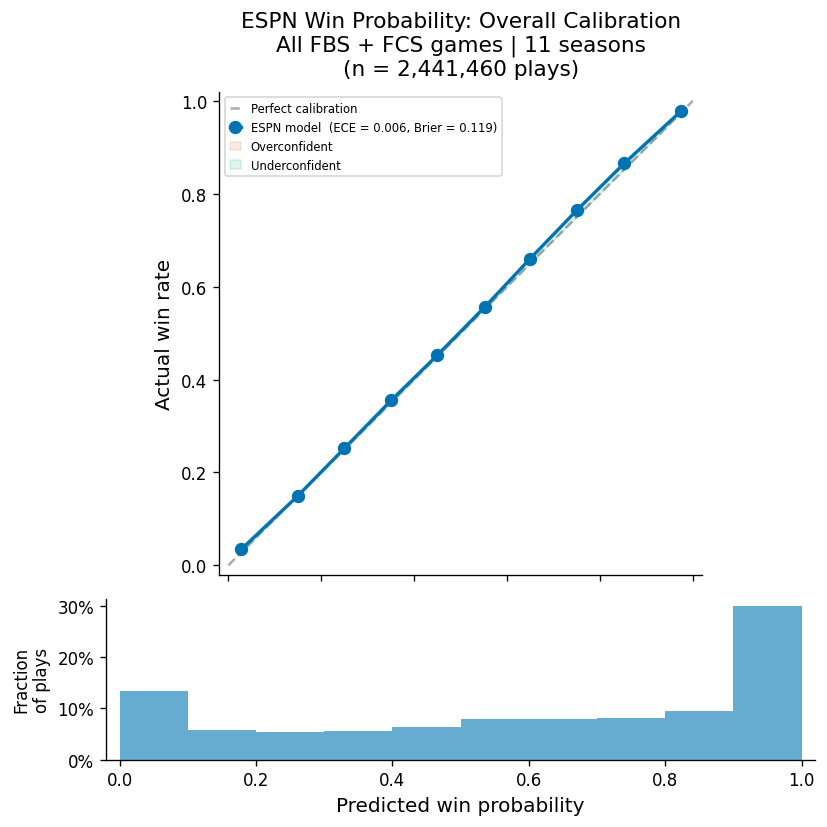

In [5]:
fig, ax = reliability_diagram(
    overall.reliability,
    title="ESPN Win Probability: Overall Calibration",
    subtitle=f"All FBS + FCS games | {plays.season.nunique()} seasons",
    ece=overall.ece,
    brier=overall.brier_score,
    n=overall.n,
)
plt.show()


---
## 2. Calibration by Game Clock

Does calibration improve as the game progresses and more information is revealed?
We expect later-game predictions to be more confident AND more accurate.


In [6]:
max_seconds = plays["total_seconds_elapsed"].max()                                                                                                                                 
bins = range(0, int(max_seconds) + 61, 60)  # +61 to include the max                                                                                                               
labels = range(1, len(bins))                                                                                                                                                       
                                                                                                                                                                                    
plays["minute_bin"] = pd.cut(                                                                                                                                                      
    plays["total_seconds_elapsed"],                                                                                                                                                
    bins=bins,                                                                                                                                                                     
    labels=labels,                                                                                                                                                                 
  )                                                                                                                                                                                  
                       

In [7]:
clock_summaries_quarter = calibration_by_segment(
    plays, "game_clock_bin",
    min_samples=500
)

clock_order = ["Q1", "Q2", "Q3", "Q4", "overtime"]
clock_ordered_quarter = {k: clock_summaries_quarter[k] for k in clock_order if k in clock_summaries_quarter}

table_quarter = calibration_summary_table(clock_ordered_quarter)
print(table_quarter.to_string(index=False))


 segment      n  brier_score  log_loss      ece      mce
      Q1 610190     0.165803  0.494628 0.008960 0.016188
      Q2 688141     0.132713  0.407796 0.010777 0.020150
      Q3 560459     0.103133  0.321824 0.009430 0.029675
      Q4 576930     0.068455  0.219858 0.011981 0.047608
overtime   5738     0.224553  0.759846 0.081482 0.219467


In [8]:
plays[plays['is_overtime']]['minute_bin'].unique()

[70, 80, 90, 100, 110, 120, 130, 67]
Categories (131, int64): [1 < 2 < 3 < 4 ... 128 < 129 < 130 < 131]

In [9]:
clock_summaries_minute = calibration_by_segment(
    plays, "minute_bin", n_bins=1,
    min_samples=5
)
table_min = calibration_summary_table(clock_summaries_minute)
print(table_min.to_string(index=False))



segment      n  brier_score  log_loss      ece      mce
      1  28593     0.179583  0.525797 0.010766 0.010766
      2  31873     0.176373  0.522056 0.005276 0.005276
      3  34140     0.172291  0.511379 0.009429 0.009429
      4  35892     0.172066  0.510511 0.001464 0.001464
      5  36442     0.173999  0.515337 0.001863 0.001863
      6  37040     0.164128  0.491561 0.006404 0.006404
      7  36932     0.164329  0.490090 0.003551 0.003551
      8  36980     0.164547  0.492258 0.003659 0.003659
      9  35857     0.161198  0.484403 0.003073 0.003073
     10  36100     0.159851  0.480487 0.003785 0.003785
     11  35784     0.159208  0.478662 0.003227 0.003227
     12  34721     0.156210  0.471295 0.002196 0.002196
     13  31446     0.155847  0.468839 0.000151 0.000151
     14  27685     0.146884  0.446844 0.000969 0.000969
     15  72876     0.153575  0.464130 0.001104 0.001104
     16  41191     0.147423  0.447648 0.002649 0.002649
     17  34717     0.146704  0.445880 0.000360 0

In [10]:
def get_begin_segment_ote(plays, labels, period = 'minute_bin'):
    
    ote_by_quarter = {}
    
    for segment in labels:
        plays_subset = plays[plays[period]==segment].copy()
        #first = plays_subset.sort_values("total_seconds_elapsed").groupby("game_id").first()
        total_predicted_wins = plays_subset['home_win_prob'].sum()
        total_actual_wins = plays_subset['actual_home_win'].sum()

        observed_to_expected = total_actual_wins / total_predicted_wins
        print(f'overall observed wins to expected wins, begin {segment}: {observed_to_expected}')
        ote_by_quarter[segment] = observed_to_expected
    return pd.DataFrame(ote_by_quarter, index = ["game_segment"])

In [11]:
ote_by_minute = get_begin_segment_ote(plays, labels=labels, period='minute_bin')

overall observed wins to expected wins, begin 1: 1.0173890491374393
overall observed wins to expected wins, begin 2: 0.9913885925110354
overall observed wins to expected wins, begin 3: 1.0153027570592243
overall observed wins to expected wins, begin 4: 0.997615070372626
overall observed wins to expected wins, begin 5: 0.9969584547608903
overall observed wins to expected wins, begin 6: 1.0104437544997251
overall observed wins to expected wins, begin 7: 0.9941930834555751
overall observed wins to expected wins, begin 8: 1.0059907408296984
overall observed wins to expected wins, begin 9: 0.9949983457477201
overall observed wins to expected wins, begin 10: 1.006164908980181
overall observed wins to expected wins, begin 11: 1.0052639312245195
overall observed wins to expected wins, begin 12: 0.9964125431892265
overall observed wins to expected wins, begin 13: 0.9997549316822312
overall observed wins to expected wins, begin 14: 1.0015858156493354
overall observed wins to expected wins, begin

/tmp/ipykernel_1012609/4208046260.py:11: RuntimeWarning: invalid value encountered in scalar divide
  observed_to_expected = total_actual_wins / total_predicted_wins


overall observed wins to expected wins, begin 62: nan
overall observed wins to expected wins, begin 63: nan
overall observed wins to expected wins, begin 64: nan
overall observed wins to expected wins, begin 65: nan
overall observed wins to expected wins, begin 66: nan
overall observed wins to expected wins, begin 67: 1.8903591682419658
overall observed wins to expected wins, begin 68: nan
overall observed wins to expected wins, begin 69: nan
overall observed wins to expected wins, begin 70: 1.0581994013516618
overall observed wins to expected wins, begin 71: nan
overall observed wins to expected wins, begin 72: nan
overall observed wins to expected wins, begin 73: nan
overall observed wins to expected wins, begin 74: nan
overall observed wins to expected wins, begin 75: nan
overall observed wins to expected wins, begin 76: nan
overall observed wins to expected wins, begin 77: nan
overall observed wins to expected wins, begin 78: nan
overall observed wins to expected wins, begin 79: na

In [12]:
ote_by_minute

,1,2,3,4,5,6,7,8,9,10,...,122,123,124,125,126,127,128,129,130,131
game_segment,1.017389,0.991389,1.015303,0.997615,0.996958,1.010444,0.994193,1.005991,0.994998,1.006165,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.897533,NaN


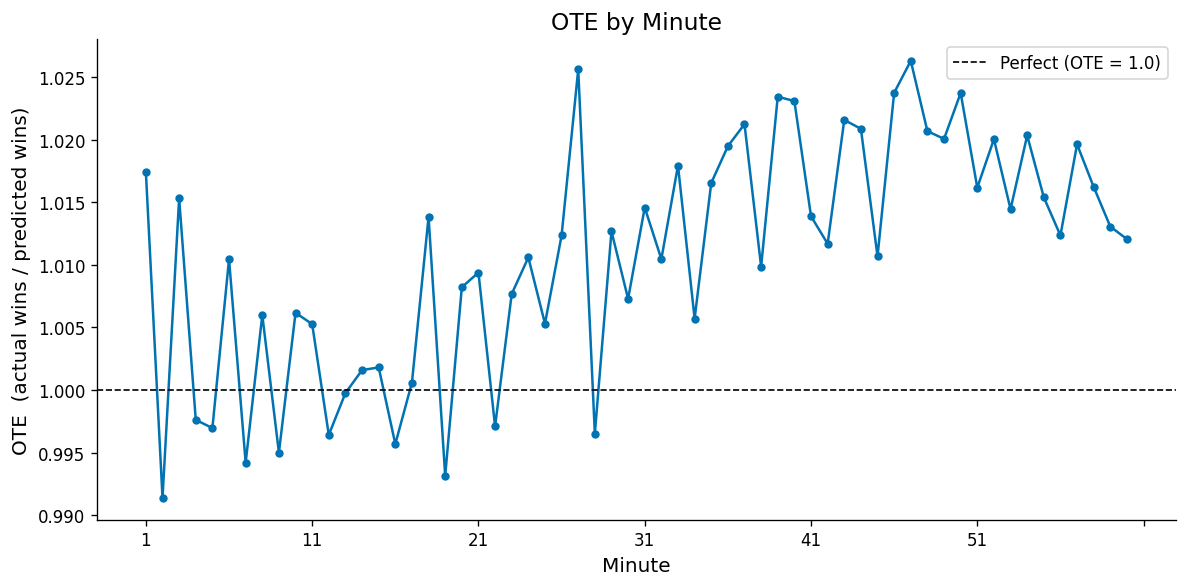

In [13]:
fig, ax = ote_by_period(ote_by_minute.iloc[:, :60], title="OTE by Minute", xlabel="Minute")
plt.show()


In [14]:
def ece_by_segement(plays, labels, period='minute_bin'):
    ece_by_quarter = {}    
    for segment in labels:
            plays_subset = plays[plays[period]==segment].copy()
            preds = plays_subset['home_win_prob'].mean()
            actual = plays_subset['actual_home_win'].mean()

            gap = np.abs(preds - actual)
            ece = gap.mean()

            print(f'ece for quarter {segment}: {ece}')
            ece_by_quarter[segment] = ece
    return pd.DataFrame(ece_by_quarter, index = ["game_segment"])

In [15]:
ece_by_minute = ece_by_segement(plays, labels=labels, period='minute_bin')

ece for quarter 1: 0.010766309935998253
ece for quarter 2: 0.005275822796724561
ece for quarter 3: 0.009428678968951498
ece for quarter 4: 0.0014638053048032784
ece for quarter 5: 0.0018632950990614683
ece for quarter 6: 0.006403793196544272
ece for quarter 7: 0.0035508068883352006
ece for quarter 8: 0.003659031909140076
ece for quarter 9: 0.0030725465041693267
ece for quarter 10: 0.0037847368421053407
ece for quarter 11: 0.0032266348088531016
ece for quarter 12: 0.002196247227902459
ece for quarter 13: 0.00015057240984539533
ece for quarter 14: 0.0009694274878092601
ece for quarter 15: 0.0011042263570996136
ece for quarter 16: 0.0026489500133524135
ece for quarter 17: 0.00035993893481578443
ece for quarter 18: 0.008495586874897931
ece for quarter 19: 0.004176274298056226
ece for quarter 20: 0.004953362612491352
ece for quarter 21: 0.005748294686773736
ece for quarter 22: 0.0017814513450681302
ece for quarter 23: 0.004667439235872206
ece for quarter 24: 0.006451558860893547
ece for qua

In [16]:
ece_by_minute

,1,2,3,4,5,6,7,8,9,10,...,122,123,124,125,126,127,128,129,130,131
game_segment,0.010766,0.005276,0.009429,0.001464,0.001863,0.006404,0.003551,0.003659,0.003073,0.003785,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.473,NaN


/home/jrlewi/college_football_calibration_study/notebooks/../cfb_calibration/visualization/plots.py:515: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


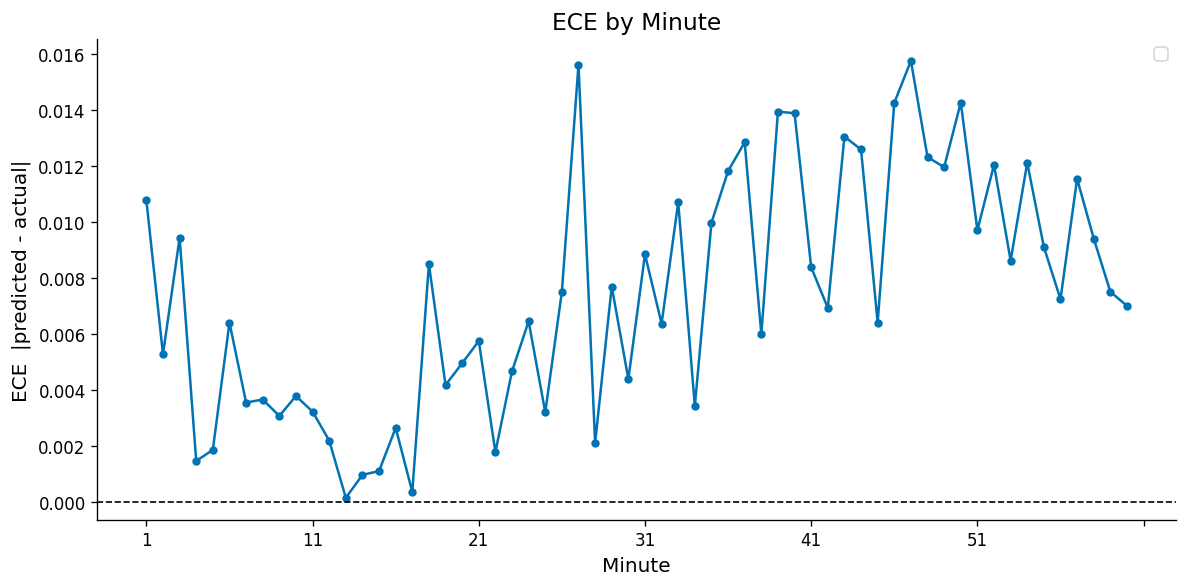

In [17]:
from cfb_calibration.visualization.plots import ece_by_period
fig, ax = ece_by_period(ece_by_minute.iloc[:, :60], title="ECE by Minute", xlabel="Minute")
plt.show()

In [18]:
clock_summaries_minute

{'1': CalibrationSummary(n=28593, brier=0.1796, ece=0.0108, mce=0.0108, log_loss=0.5258),
 '2': CalibrationSummary(n=31873, brier=0.1764, ece=0.0053, mce=0.0053, log_loss=0.5221),
 '3': CalibrationSummary(n=34140, brier=0.1723, ece=0.0094, mce=0.0094, log_loss=0.5114),
 '4': CalibrationSummary(n=35892, brier=0.1721, ece=0.0015, mce=0.0015, log_loss=0.5105),
 '5': CalibrationSummary(n=36442, brier=0.1740, ece=0.0019, mce=0.0019, log_loss=0.5153),
 '6': CalibrationSummary(n=37040, brier=0.1641, ece=0.0064, mce=0.0064, log_loss=0.4916),
 '7': CalibrationSummary(n=36932, brier=0.1643, ece=0.0036, mce=0.0036, log_loss=0.4901),
 '8': CalibrationSummary(n=36980, brier=0.1645, ece=0.0037, mce=0.0037, log_loss=0.4923),
 '9': CalibrationSummary(n=35857, brier=0.1612, ece=0.0031, mce=0.0031, log_loss=0.4844),
 '10': CalibrationSummary(n=36100, brier=0.1599, ece=0.0038, mce=0.0038, log_loss=0.4805),
 '11': CalibrationSummary(n=35784, brier=0.1592, ece=0.0032, mce=0.0032, log_loss=0.4787),
 '12': C

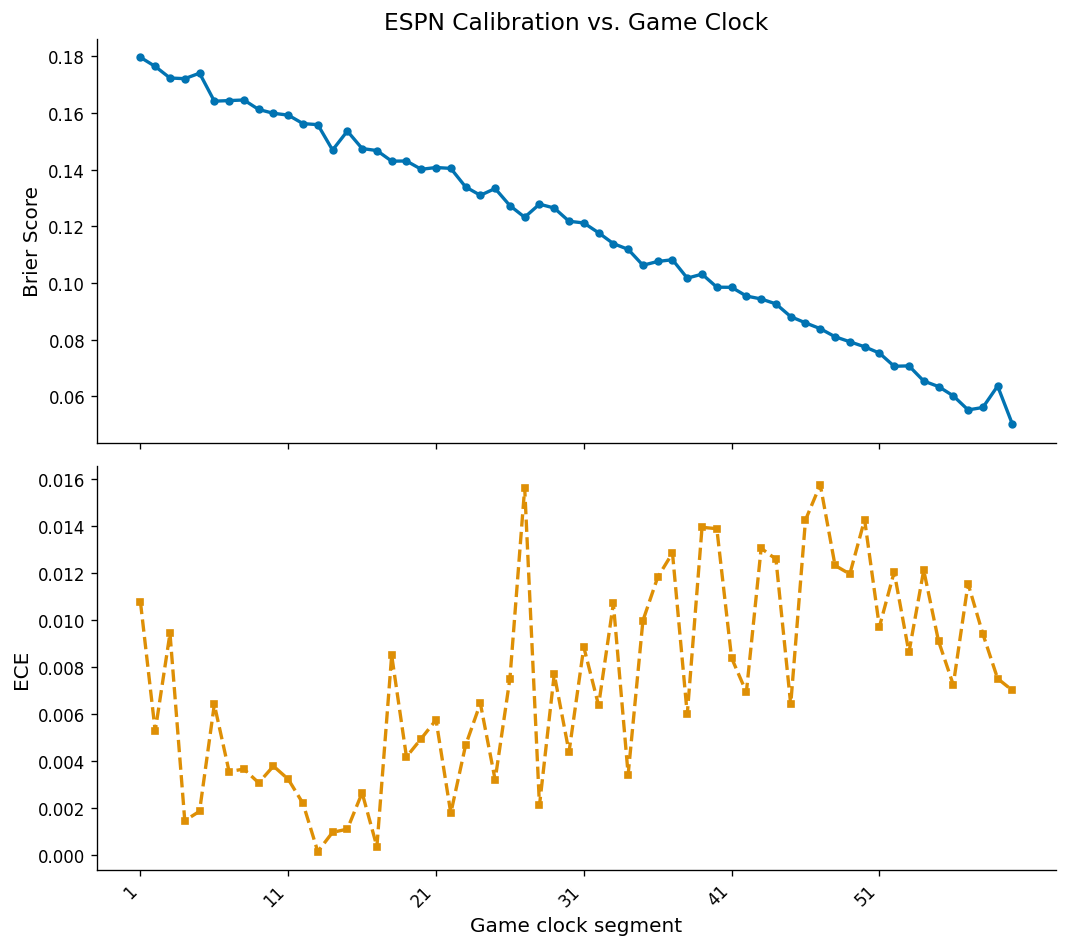

In [19]:
fig, axes = brier_ece_by_clock(
    clock_summaries_minute,
    title="ESPN Calibration vs. Game Clock", 
    dual_plot=False, 
    max_index=60
)
plt.show()


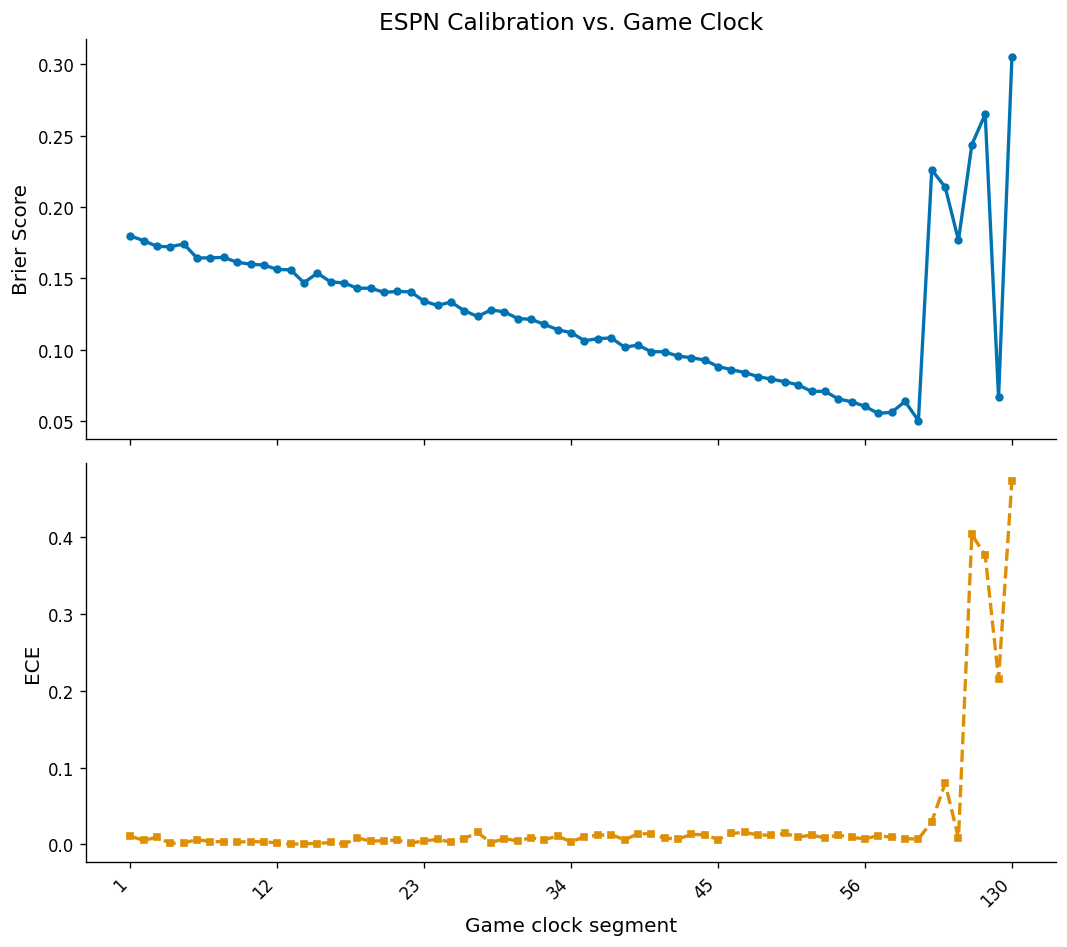

In [20]:
fig, axes = brier_ece_by_clock(
    clock_summaries_minute,
    title="ESPN Calibration vs. Game Clock", 
    dual_plot=False, 
    max_index=None
)
plt.show()

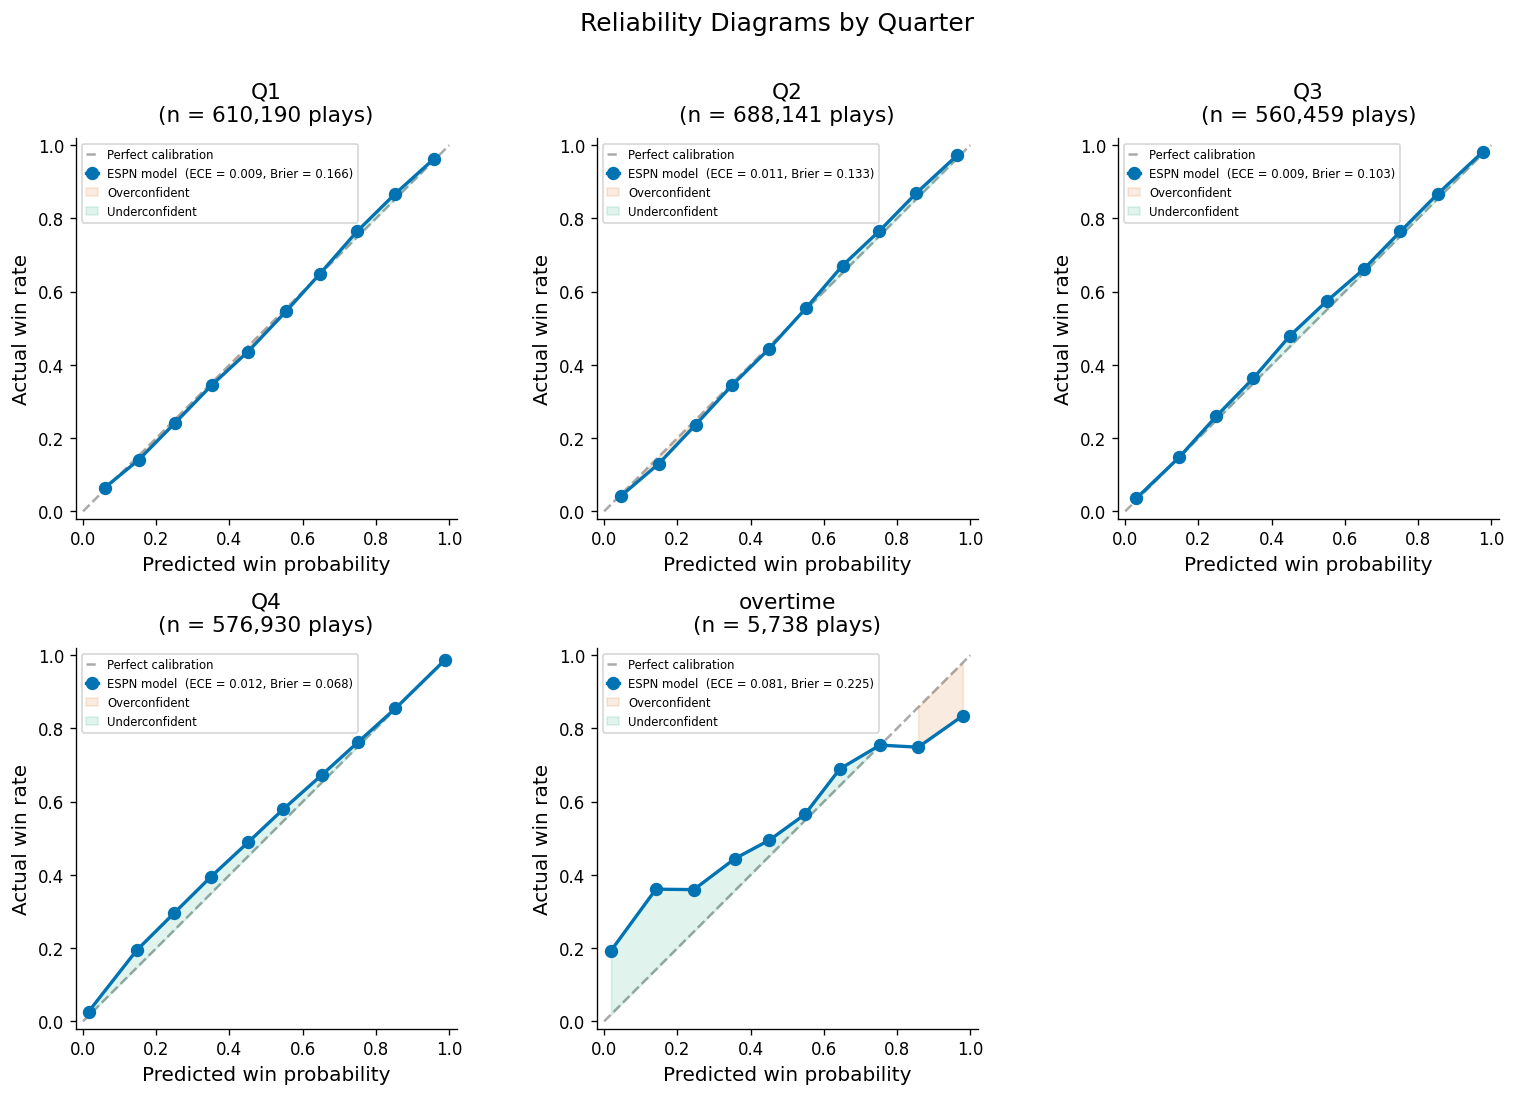

In [21]:
fig, axes = reliability_diagram_grid(
    clock_ordered_quarter,
    cols=3,
    title="Reliability Diagrams by Quarter"
)
plt.show()


In [22]:
clock_ordered_quarter['overtime'].reliability

ReliabilityData(bin_edges=array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]), bin_centers=array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]), mean_predicted=array([0.01884579, 0.14147929, 0.24479373, 0.35747488, 0.45153674,
       0.54814252, 0.64386569, 0.7534784 , 0.85771813, 0.97958125]), actual_fraction=array([0.19301848, 0.36094675, 0.35973597, 0.44461778, 0.49508841,
       0.56500489, 0.68954248, 0.75443787, 0.74870466, 0.83445946]), counts=array([ 487,  338,  303,  641, 1018, 1023,  612,  338,  386,  592]), calibration_gap=array([-0.17417269, -0.21946746, -0.11494224, -0.0871429 , -0.04355167,
       -0.01686237, -0.0456768 , -0.00095947,  0.10901347,  0.14512179]))

---
## 3. Score Differential Analysis

Is the model calibrated when the game is close? When it's a blowout?
Extreme score differentials might cause the model to be overconfident (e.g. predicting 98% when up 28 in Q4, but some of those games still get close).



In [23]:
score_summaries = calibration_by_segment(
    plays, "score_differential_bin",
    min_samples=500
)
table_score = calibration_summary_table(score_summaries)
print(table_score.sort_values("ece", ascending=False).to_string(index=False))


     segment      n  brier_score  log_loss      ece      mce
  home_close 485359     0.160196  0.486606 0.012905 0.025772
  away_small 303356     0.151297  0.467209 0.011355 0.039162
  home_small 306239     0.078907  0.272350 0.009460 0.945356
home_blowout 145739     0.003430  0.013692 0.008304 0.945000
 away_medium 145623     0.062382  0.225252 0.007926 0.410467
  away_close 632723     0.201031  0.584539 0.007466 0.039622
 home_medium 184481     0.023940  0.100089 0.005517 0.951000
  home_large 112546     0.006770  0.032936 0.003810 0.972000
  away_large  67896     0.016566  0.071352 0.002633 0.508083
away_blowout  57477     0.003158  0.017905 0.001136 0.749333


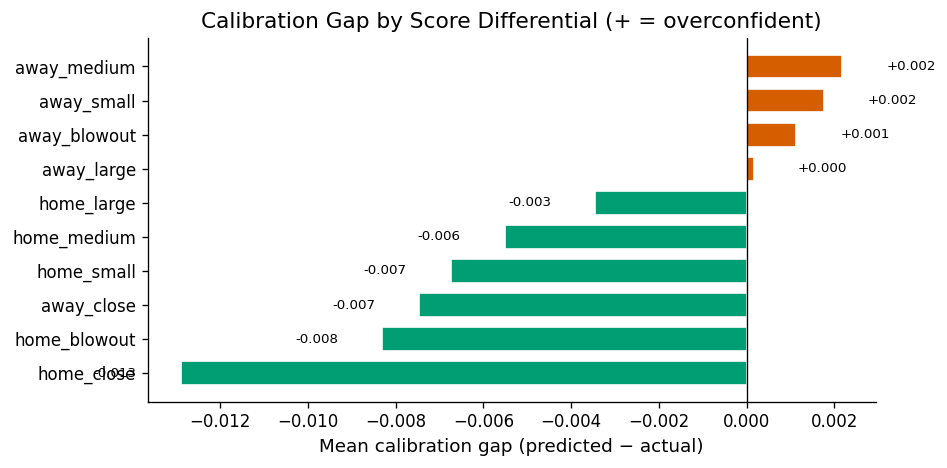

In [24]:
fig, ax = calibration_gap_distribution(
    score_summaries,
    title="Calibration Gap by Score Differential (+ = overconfident)"
)
plt.show()


---
## 4. The 2D View: Clock × Score Differential Heatmap

The most revealing analysis: how calibration error varies simultaneously
across game time and score margin.


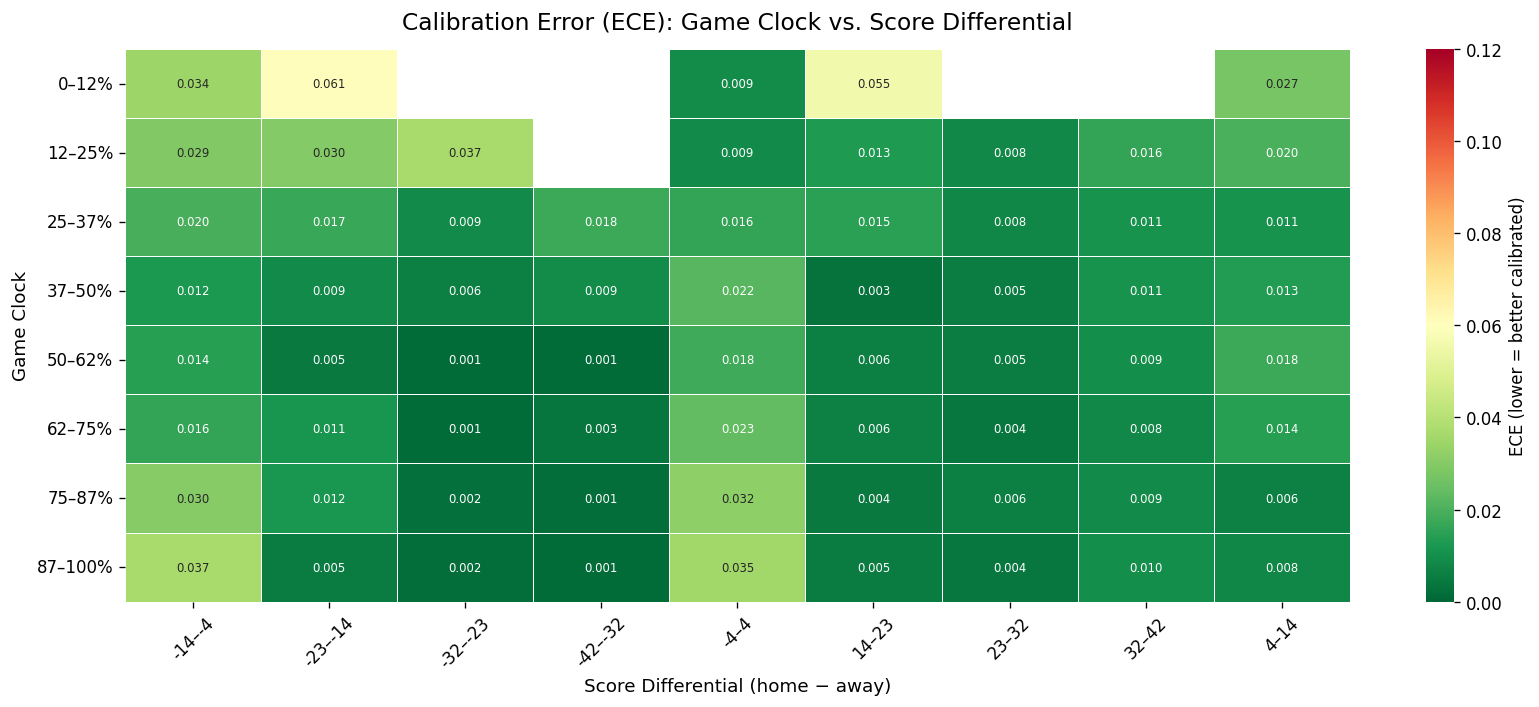

In [25]:
ece_pivot, count_pivot = clock_score_diff_grid(
    plays,
    clock_bins=8,
    score_bins=9,
    min_samples=100
)

fig, ax = calibration_heatmap(
    ece_pivot,
    title="Calibration Error (ECE): Game Clock vs. Score Differential",
    xlabel="Score Differential (home − away)",
    ylabel="Game Clock",
    vmax=0.12,
)
plt.show()


---
## 5. Down & Distance

Does the model calibrate differently based on the game situation?


In [26]:
down_summaries = calibration_by_segment(
    plays.dropna(subset=["down_distance_situation"]),
    "down_distance_situation",
    min_samples=200
)
table_down = calibration_summary_table(down_summaries)
print(table_down.to_string(index=False))


              segment       n  brier_score  log_loss      ece      mce
             goalline   86839     0.116597  0.363916 0.006617 0.018371
        short_yardage  261413     0.117909  0.363403 0.006697 0.017221
             standard 1641570     0.119781  0.367236 0.006209 0.013385
third_fourth_and_long  451638     0.118465  0.364380 0.005977 0.019799


---
## 6. Conference Tier

Do predictions for power conference games differ in calibration from Group of 5 or FCS games?


  segment       n  brier_score  log_loss      ece      mce
G5_or_FCS 1630996     0.124811  0.382156 0.007596 0.022415
       P5  810464     0.107981  0.334025 0.006044 0.019916


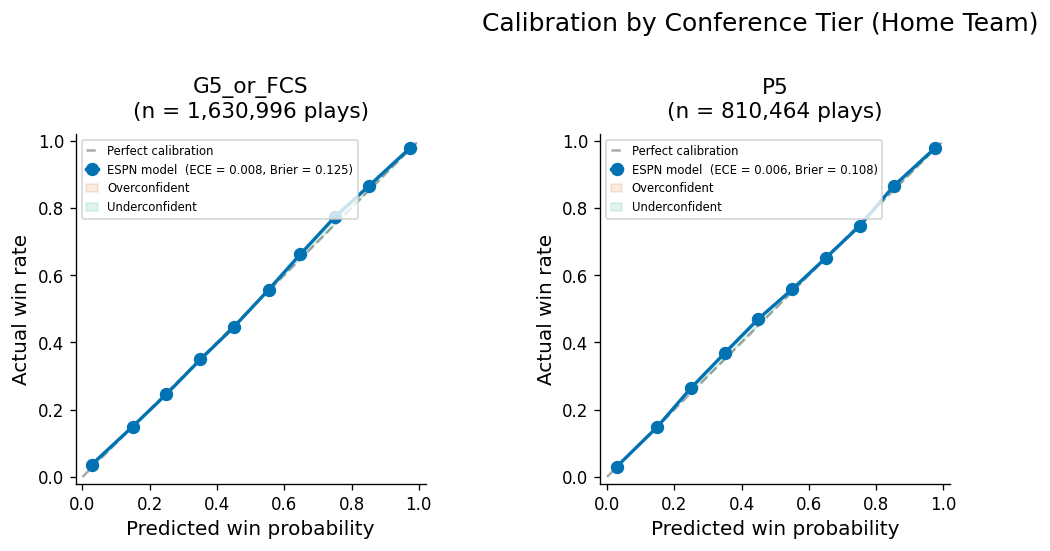

In [27]:
tier_summaries = calibration_by_segment(
    plays.dropna(subset=["conference_tier_home"]),
    "conference_tier_home",
    min_samples=500
)
table_tier = calibration_summary_table(tier_summaries)
print(table_tier.to_string(index=False))

fig, axes = reliability_diagram_grid(
    tier_summaries, cols=3,
    title="Calibration by Conference Tier (Home Team)"
)
plt.show()


In [28]:
# what is OTE when prior prediction is close to average

pregame = pregame.copy()
pregame["near_0.6"] = pregame["home_win_prob"].between(0.55, 0.65)
print(f"near_0.6: {pregame['near_0.6'].sum():,} games  |  other: {(~pregame['near_0.6']).sum():,} games\n")

cat_vars = ["conference_tier_home", "group"]
for col in cat_vars:
    ct = pd.crosstab(pregame[col], pregame["near_0.6"])
    ct.columns = ["Other", "Near 0.6"]
    ct["pct_near_0.6"] = (ct["Near 0.6"] / ct.sum(axis=1) * 100).round(1)
    ct = ct.sort_values("pct_near_0.6", ascending=False).head(10)
    print(f"--- {col} ---")
    print(ct.to_string())
    print()

# Attendance (in games_df, merge in)
print("--- attendance ---")
print(pregame.groupby("near_0.6")["attendance"].describe().round(0).T.to_string())


near_0.6: 4,034 games  |  other: 10,066 games

--- conference_tier_home ---
                      Other  Near 0.6  pct_near_0.6
conference_tier_home                               
G5_or_FCS              5948      3600          37.7
P5                     4118       434           9.5

--- group ---
       Other  Near 0.6  pct_near_0.6
group                               
81      3190      3115          49.4
80      6876       919          11.8

--- attendance ---
near_0.6     False     True 
count      10066.0    4034.0
mean       31605.0   13523.0
std        27778.0   17587.0
min            0.0       0.0
25%         9418.0    3645.0
50%        22348.0    7179.0
75%        48264.0   15159.0
max       156990.0  111519.0


In [29]:
pregame.columns

Index(['play_id', 'season', 'period', 'is_overtime', 'clock_display',
       'clock_seconds_remaining_period', 'total_seconds_elapsed',
       'game_clock_pct', 'home_score', 'away_score', 'score_differential',
       'down', 'distance', 'yard_line', 'yards_to_endzone', 'yards_gained',
       'play_type', 'play_description', 'is_scoring_play', 'home_win_prob',
       'actual_home_win', 'home_score_final', 'away_score_final',
       'season_type', 'week', 'home_team', 'away_team', 'home_conference',
       'away_conference', 'group', 'neutral_site', 'attendance',
       'went_to_overtime', 'pre_game_spread', 'over_under', 'weather_temp_f',
       'weather_condition', 'score_differential_bin', 'game_clock_bin',
       'down_distance_situation', 'conference_tier_home',
       'conference_tier_away', 'game_tier', 'spread_category',
       'implied_home_win_prob_vegas', 'near_0.6'],
      dtype='str')

In [30]:
mask = pregame["near_0.6"]
pregrame_near_games = pregame[mask].copy()
game_ids_near = pregrame_near_games.index
plays_pregame_near = plays[plays["game_id"].isin(game_ids_near)]


pregame_not_near_games = pregame[~mask].copy()
game_ids_not_near = pregame_not_near_games.index
plays_pregame_not_near = plays[plays["game_id"].isin(game_ids_not_near)]

In [31]:
plays_pregame_near.sort_values("total_seconds_elapsed")["home_win_prob"]

39685      0.6220
1076584    0.6310
2232879    0.6176
2232878    0.6199
2232877    0.6096
            ...  
731004     0.3600
731009     0.5440
731005     0.5350
731003     0.3910
731007     0.1590
Name: home_win_prob, Length: 685115, dtype: float64

In [32]:
clock_summaries_near = calibration_by_segment(
    plays_pregame_near, "game_clock_bin",
    min_samples=500
)

clock_order = ["Q1", "Q2", "Q3", "Q4", "overtime"]
clock_ordered = {k: clock_summaries_near[k] for k in clock_order if k in clock_summaries_near}

table = calibration_summary_table(clock_summaries_near)
print(table.to_string(index=False))


 segment      n  brier_score  log_loss      ece      mce
      Q1 173284     0.205560  0.596114 0.032227 0.092254
      Q2 191385     0.156189  0.472802 0.019745 0.048394
      Q3 157396     0.117340  0.362217 0.012040 0.035819
      Q4 161370     0.074019  0.239485 0.013130 0.038037
overtime   1680     0.224875  0.750236 0.095509 0.353971


In [34]:
clock_summaries_not_near = calibration_by_segment(
    plays_pregame_not_near, "game_clock_bin",
    min_samples=500
)

clock_order = ["Q1", "Q2", "Q3", "Q4", "overtime"]
clock_ordered = {k: clock_summaries_not_near[k] for k in clock_order if k in clock_summaries_near}

table = calibration_summary_table(clock_summaries_not_near)
print(table.to_string(index=False))

 segment      n  brier_score  log_loss      ece      mce
      Q1 436906     0.150035  0.454378 0.006187 0.013776
      Q2 496756     0.123668  0.382751 0.008224 0.018332
      Q3 403063     0.097585  0.306051 0.008495 0.026529
      Q4 415560     0.066294  0.212237 0.012166 0.058654
overtime   4058     0.224420  0.763824 0.080224 0.181111


In [35]:
ote_by_quarter = get_begin_segment_ote(plays, labels=clock_ordered_quarter, period='game_clock_bin')

overall observed wins to expected wins, begin Q1: 1.0009299937511054
overall observed wins to expected wins, begin Q2: 1.0065649576084323
overall observed wins to expected wins, begin Q3: 1.0156575511320725
overall observed wins to expected wins, begin Q4: 1.0180219732682863
overall observed wins to expected wins, begin overtime: 1.0719488533480106


In [36]:
ote_by_quarter = get_begin_segment_ote(plays_pregame_not_near, labels=clock_ordered_quarter, period='game_clock_bin')

overall observed wins to expected wins, begin Q1: 0.9999917618888952
overall observed wins to expected wins, begin Q2: 1.0048259358227722
overall observed wins to expected wins, begin Q3: 1.0139764910421027
overall observed wins to expected wins, begin Q4: 1.018173921335254
overall observed wins to expected wins, begin overtime: 1.0574006037369412


In [37]:
ote_by_quarter = get_begin_segment_ote(plays_pregame_near, labels=clock_ordered_quarter, period='game_clock_bin')

overall observed wins to expected wins, begin Q1: 1.0033601905422906
overall observed wins to expected wins, begin Q2: 1.0112107743715326
overall observed wins to expected wins, begin Q3: 1.0201061522660808
overall observed wins to expected wins, begin Q4: 1.01762332132588
overall observed wins to expected wins, begin overtime: 1.1060797631441706


In [38]:
def compute_pregame_ote(pregame):
    preds = pregame["home_win_prob"]
    actual = pregame["actual_home_win"]
    return actual.sum() / preds.sum()


In [39]:
pregame.columns

Index(['play_id', 'season', 'period', 'is_overtime', 'clock_display',
       'clock_seconds_remaining_period', 'total_seconds_elapsed',
       'game_clock_pct', 'home_score', 'away_score', 'score_differential',
       'down', 'distance', 'yard_line', 'yards_to_endzone', 'yards_gained',
       'play_type', 'play_description', 'is_scoring_play', 'home_win_prob',
       'actual_home_win', 'home_score_final', 'away_score_final',
       'season_type', 'week', 'home_team', 'away_team', 'home_conference',
       'away_conference', 'group', 'neutral_site', 'attendance',
       'went_to_overtime', 'pre_game_spread', 'over_under', 'weather_temp_f',
       'weather_condition', 'score_differential_bin', 'game_clock_bin',
       'down_distance_situation', 'conference_tier_home',
       'conference_tier_away', 'game_tier', 'spread_category',
       'implied_home_win_prob_vegas', 'near_0.6'],
      dtype='str')

In [40]:
pregame.groupby("near_0.6").apply(compute_pregame_ote)                                                                                                                            

near_0.6
False    1.001575
True     1.003097
dtype: float64

In [41]:
clock_summaries_minute = calibration_by_segment(
    plays, "minute_bin", n_bins=1,
    min_samples=5
)
table_min = calibration_summary_table(clock_summaries_minute)
print(table_min.to_string(index=False))


segment      n  brier_score  log_loss      ece      mce
      1  28593     0.179583  0.525797 0.010766 0.010766
      2  31873     0.176373  0.522056 0.005276 0.005276
      3  34140     0.172291  0.511379 0.009429 0.009429
      4  35892     0.172066  0.510511 0.001464 0.001464
      5  36442     0.173999  0.515337 0.001863 0.001863
      6  37040     0.164128  0.491561 0.006404 0.006404
      7  36932     0.164329  0.490090 0.003551 0.003551
      8  36980     0.164547  0.492258 0.003659 0.003659
      9  35857     0.161198  0.484403 0.003073 0.003073
     10  36100     0.159851  0.480487 0.003785 0.003785
     11  35784     0.159208  0.478662 0.003227 0.003227
     12  34721     0.156210  0.471295 0.002196 0.002196
     13  31446     0.155847  0.468839 0.000151 0.000151
     14  27685     0.146884  0.446844 0.000969 0.000969
     15  72876     0.153575  0.464130 0.001104 0.001104
     16  41191     0.147423  0.447648 0.002649 0.002649
     17  34717     0.146704  0.445880 0.000360 0

---
## 7. ESPN vs. Vegas Pre-game Predictions

How does ESPN's pre-game win probability compare to the market consensus (Vegas implied probability)?

> Note: requires CFBD lines data. If  is mostly null, run Step 3 in notebook 01 first.


In [42]:
plays.columns

Index(['game_id', 'play_id', 'season', 'period', 'is_overtime',
       'clock_display', 'clock_seconds_remaining_period',
       'total_seconds_elapsed', 'game_clock_pct', 'home_score', 'away_score',
       'score_differential', 'down', 'distance', 'yard_line',
       'yards_to_endzone', 'yards_gained', 'play_type', 'play_description',
       'is_scoring_play', 'home_win_prob', 'actual_home_win',
       'home_score_final', 'away_score_final', 'season_type', 'week',
       'home_team', 'away_team', 'home_conference', 'away_conference', 'group',
       'neutral_site', 'attendance', 'went_to_overtime', 'pre_game_spread',
       'over_under', 'weather_temp_f', 'weather_condition',
       'score_differential_bin', 'game_clock_bin', 'down_distance_situation',
       'conference_tier_home', 'conference_tier_away', 'game_tier',
       'spread_category', 'implied_home_win_prob_vegas', 'minute_bin'],
      dtype='str')

In [43]:
# Use only the first play of each game (pre-game prediction)
pregame2 = (
    plays.sort_values("total_seconds_elapsed")
    .groupby("game_id", as_index=False)
    .first()
)


espn_cal = calibration_summary(
    pregame2["home_win_prob"].values,
    pregame2["actual_home_win"].values,
    label="ESPN pre-game"
)
print("ESPN pre-game calibration:", espn_cal)

if pregame2["implied_home_win_prob_vegas"].notna().sum() > 100:
    vegas_cal = calibration_summary(
        pregame2["implied_home_win_prob_vegas"].dropna().values,
        pregame2.loc[pregame2["implied_home_win_prob_vegas"].notna(), "actual_home_win"].values,
        label="Vegas implied"
    )
    print("Vegas implied calibration:", vegas_cal)
else:
    print("Not enough Vegas lines data. Run collect_lines in notebook 01.")


ESPN pre-game calibration: CalibrationSummary(n=14100, brier=0.1843, ece=0.0097, mce=0.0370, log_loss=0.5389)
Vegas implied calibration: CalibrationSummary(n=6953, brier=0.1618, ece=0.0241, mce=0.0538, log_loss=0.4875)


In [44]:
# Use ESPN's first-play win probability as the pre-game probability                                                                                                                                                 
# (identical in practice — it's the model's state before any plays affect the score)                                                                                                                                
pregame2["espn_home_prob_pregame"] = pregame2["home_win_prob"]                                                                                                                                                        
              
print(pregame2["espn_home_prob_pregame"].notna().sum())                                                                                                                                                              


14100


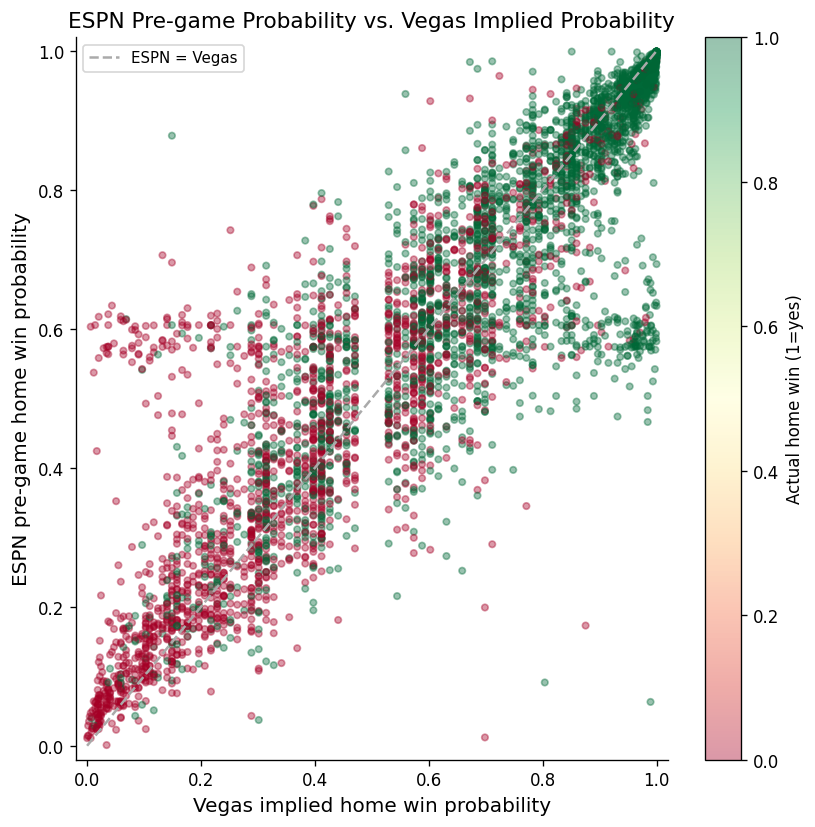

In [45]:
if pregame2["implied_home_win_prob_vegas"].notna().sum() > 100:
    fig, ax = espn_vs_vegas_scatter(pregame2)
    plt.show()


---
## 8. Season Trend: Is ESPN Getting Better?

Has ESPN's model improved over the years?


In [46]:
print(pregame2["implied_home_win_prob_vegas"].notna().sum())                                                                                                                                                         
print(pregame2["pre_game_spread"].notna().sum())
                                                                                                                                                                                                                  
#If both are low, the issue is the team name matching between ESPN and CFBD. You can check a sample:                                                                                                                 

# See what ESPN team names look like vs CFBD                                                                                                                                                                        
print(pregame2[["home_team", "pre_game_spread"]].head(20))    

6953
6953
                     home_team  pre_game_spread
0         Tennessee Volunteers              2.5
1             Georgia Bulldogs            -16.0
2                 Baylor Bears            -48.5
3                 Baylor Bears            -28.5
4                 Baylor Bears            -10.0
5          Iowa State Cyclones             17.0
6                 Baylor Bears            -35.0
7              Texas Longhorns              3.5
8                 Baylor Bears             -9.0
9             Oklahoma Sooners            -15.5
10                Baylor Bears              2.0
11      Texas Tech Red Raiders              2.5
12  West Virginia Mountaineers            -14.5
13         Iowa State Cyclones            -11.0
14               Iowa Hawkeyes            -18.0
15            TCU Horned Frogs            -23.5
16                 Temple Owls            -21.5
17          Army Black Knights             -7.0
18                 UTEP Miners              NaN
19               Buffalo Bulls

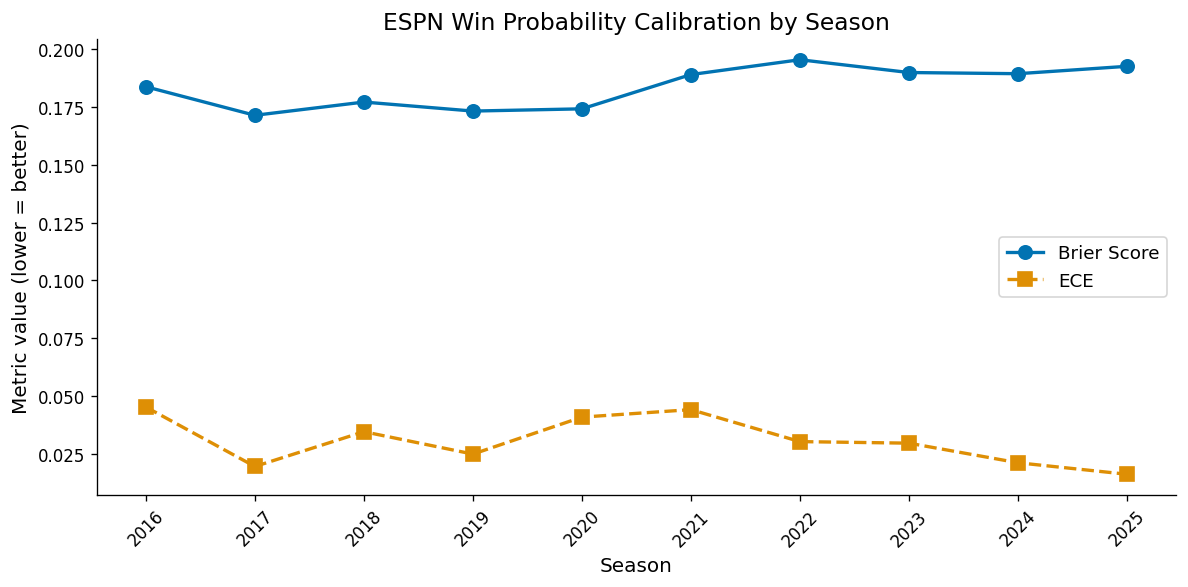

segment    n  brier_score  log_loss      ece      mce
   2016 1432     0.183802  0.540933 0.045142 0.107058
   2017 1484     0.171435  0.509374 0.019400 0.067225
   2018 1455     0.177168  0.521029 0.034464 0.089647
   2019 1554     0.173265  0.513132 0.024764 0.113548
   2020  584     0.174233  0.518883 0.040770 0.109156
   2021 1405     0.189064  0.551689 0.044017 0.120230
   2022 1416     0.195492  0.564043 0.030171 0.071424
   2023 1517     0.189950  0.551324 0.029498 0.117720
   2024 1585     0.189442  0.548211 0.021016 0.076095
   2025 1666     0.192639  0.557604 0.016039 0.075279


In [47]:
season_summaries = calibration_by_segment(
    pregame2, "season",
    min_samples=500
)

fig, ax = season_trend_plot(
    season_summaries,
    title="ESPN Win Probability Calibration by Season"
)
plt.show()

table_season = calibration_summary_table(season_summaries)
print(table_season.sort_values("segment").to_string(index=False))


---
## 9. Overtime

OT games are particularly interesting: the model faces near-50/50 situations where
calibration is hardest to measure.


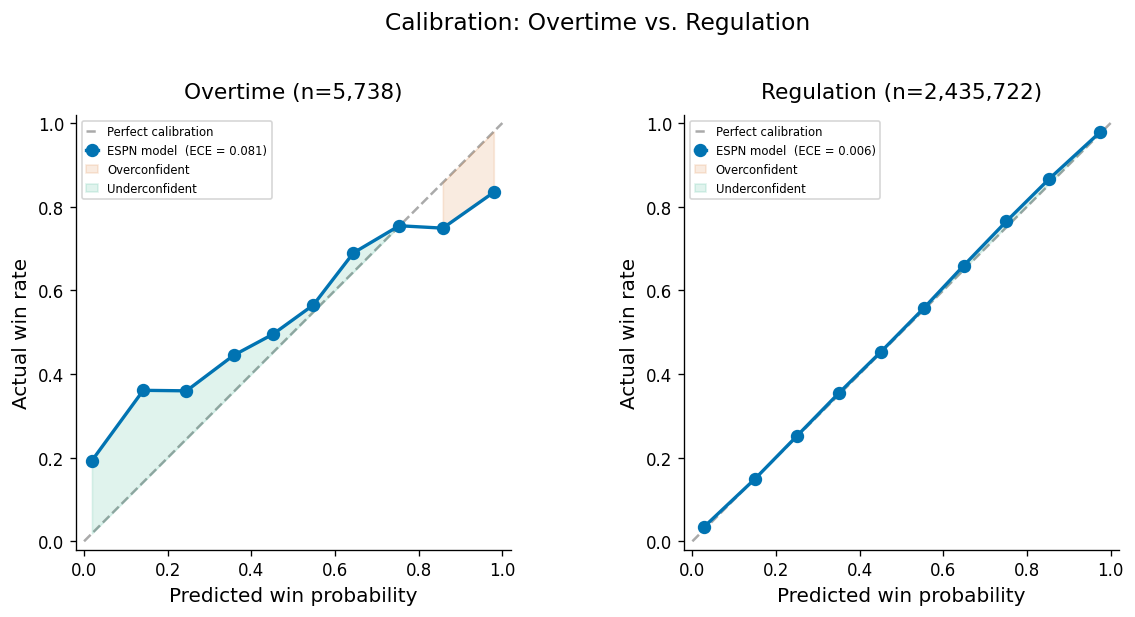

OT Brier=0.2246, ECE=0.0815
Reg Brier=0.1190, ECE=0.0060


In [48]:
ot_plays = plays[plays["is_overtime"] == True]
reg_plays = plays[plays["is_overtime"] == False]

ot_cal = calibration_summary(ot_plays["home_win_prob"].values, ot_plays["actual_home_win"].values, label="OT")
reg_cal = calibration_summary(reg_plays["home_win_prob"].values, reg_plays["actual_home_win"].values, label="Regulation")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
reliability_diagram(ot_cal.reliability, title=f"Overtime (n={ot_cal.n:,})", ece=ot_cal.ece, ax=axes[0], show_histogram=False)
reliability_diagram(reg_cal.reliability, title=f"Regulation (n={reg_cal.n:,})", ece=reg_cal.ece, ax=axes[1], show_histogram=False)
plt.suptitle("Calibration: Overtime vs. Regulation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"OT Brier={ot_cal.brier_score:.4f}, ECE={ot_cal.ece:.4f}")
print(f"Reg Brier={reg_cal.brier_score:.4f}, ECE={reg_cal.ece:.4f}")


---
## 10. Conclusions & Limitations

### Key Findings
*(Fill in after running the analysis)*

1. **Overall calibration**: …
2. **Game clock effect**: …
3. **Score differential effect**: …
4. **Conference tier differences**: …
5. **Overtime**: …
6. **ESPN vs Vegas**: …
7. **Season trend**: …

### Limitations
- ESPN's win probability model may have changed methodology over the years
- FCS game coverage is incomplete in earlier seasons
- Vegas line matching is approximate (team name normalization)
- Play-by-play data does not include penalty details, timeout usage, or drive context
- Pre-game here is defined as the first recorded play — true pre-game probabilities may differ slightly
